<a id='notebook-top'></a>

# Fibirl Tracing and Alignment with the Extrapolated Magnetic Field 
---
This notebook shows quantative comparison between the orientations of the fibrils and the extrapolated magnetic field at a height of approximately 1 Mm above the bottom boundary. The fibril tracing is performed on a combined H$\beta$ and G-band image (see Appendix A of the paper for details). The extrapolated magnetic field is obtained from a magnetohydrostatic (MHS) extrapolation using the SOT/SP photospheric vector magnetogram as the bottom boundary condition.  

Go to [Figure 5](#figure-5) and [Figure A.1](#figure-A1). 

Note: The internal hyperlink only works on [GitHub Pages](https://yjzhu-solar.github.io/DKIST_SolO_Fibril/ipynb_html/vbi_fibril_alignment.html) or [nbviewer](https://nbviewer.org/github/yjzhu-solar/DKIST_SolO_Fibril/blob/master/ipynb/ms_plot/vbi_fibril_alignment.ipynb). Do not click when viewing the notebook on GitHub.

## Import libraries and plotting configurations

In [92]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rc_context
import matplotlib.patheffects as path_effects
from matplotlib import patches
from matplotlib.ticker import AutoMinorLocator
from matplotlib.cm import ScalarMappable
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import sunpy
import sunpy.map
from sunpy.coordinates import propagate_with_solar_surface
from sunpy.coordinates.spice import get_rotation_matrix
import astropy
from astropy.coordinates import SkyCoord
import astropy.units as u
import astropy.constants as const
from astropy.io import fits, ascii
from astropy.time import Time
from astropy.convolution import convolve, Gaussian2DKernel
from astropy.wcs import WCS
from astropy.visualization import ImageNormalize, AsinhStretch
from ndcube.wcs.tools import unwrap_wcs_to_fitswcs
from copy import deepcopy
from scipy.ndimage import distance_transform_edt
import h5py 
import dask.array as da 
from ndcube import NDCube
from fancy_colorbar import plot_colorbar
import os 
import cmcrameri.cm as cmcm 
os.environ["SPICE_KERNEL_PATH"] = "/cluster/home/zhuyin/scripts/spice_kernel/"
from mag_reproject import hgs_local_to_heeq_cart
from IPython.display import HTML, display

In [2]:
ms_style_dict = {'text.usetex': True, 'font.family': 'serif', 'axes.linewidth': 1.2,
                 'xtick.major.width': 1.2, 'xtick.major.size': 4,
                 'ytick.major.width': 1.2, 'ytick.major.size': 4,
                 'xtick.minor.width': 1.2, 'xtick.minor.size': 2,
                 'ytick.minor.width': 1.2, 'ytick.minor.size': 2,
                 'xtick.direction': 'in', 'ytick.direction': 'in',
                 'text.latex.preamble': r'\usepackage[T1]{fontenc}'
                 r'\usepackage{amsmath}' r'\usepackage{siunitx}'
                 r'\sisetup{detect-all=True}' r'\usepackage{fixltx2e}'}

## Load preprocessed data

### VBI Hbeta and G-band images

In [3]:
file_Hbeta_pr = h5py.File("/cluster/home/zhuyin/work/dkist_solo_fibril_data/pid_1_123_aux/plot_ready/Hbeta_BJOLO_pr.hdf5")
Hbeta_pr_set = file_Hbeta_pr["vbi_img"]
Hbeta_pr_da = da.from_array(Hbeta_pr_set, chunks=(1, 4096 - 128*2, 4096 - 128*2))
Hbeta_date_obs = Time(ascii.read("/cluster/home/zhuyin/work/dkist_solo_fibril_data/pid_1_123_aux/plot_ready/Hbeta_BJOLO_date_avg.txt")["DATE-AVG"])

In [149]:
Gband_date_obs = Time(ascii.read("../../data/pid_1_123_aux/plot_ready/Gband_AEZDV_date_avg.txt")["DATE-AVG"])

In [4]:
dkist_vbi_target_header = fits.getheader("../../data/pid_1_123_aux/plot_ready/dkist_target_wcs_header_before_crop.fits",
                                        ignore_missing_simple=True)

dkist_vbi_target_data = np.zeros((4096,4096))

dkist_vbi_target_cube = NDCube(dkist_vbi_target_data,WCS(dkist_vbi_target_header, naxis=2))
dkist_vbi_target_cube_crop = dkist_vbi_target_cube[128:-128,128:-128]
dkist_vbi_target_cube_crop_rebin = dkist_vbi_target_cube_crop.rebin((8,8))

Set MJD-BEG to 59876.791095 from DATE-BEG.
Set MJD-AVG to 59876.791095 from DATE-AVG.
Set MJD-END to 59876.791095 from DATE-END'. [astropy.wcs.wcs]
Set OBSGEO-B to    20.706700 from OBSGEO-[XYZ].
Set OBSGEO-H to     3063.997 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


### Fibril Tracing Results

In [5]:
fibril_tracing_dict = np.load("../../sav/fibril_tracing/Hbeta_mask_reconstructed_skel_res.npz")
fibril_tracing_dict.files

['mask',
 'skeleton',
 'straight_skeleton',
 'grouped_skeleton',
 'grouped_mask',
 'n_links',
 'Hbeta_Gand_image',
 'Hbeta_image',
 'Gband_image']

In [6]:
skel_ys, skel_xs = np.nonzero(fibril_tracing_dict["grouped_skeleton"][:])

### MHS Extrapolation Results

In [7]:
mhs_ex_slice_dict = np.load("../../data/pid_1_123_aux/MHSXtra_results/SOTSP_test_full_v2_slice/SOTSP_test_full_v2_slice.npz")
mhs_ex_slice_dict.files

['bx_v2_sliced', 'by_v2_sliced', 'bz_v2_sliced']

In [8]:
bx_v2_sliced = mhs_ex_slice_dict["bx_v2_sliced"]
by_v2_sliced = mhs_ex_slice_dict["by_v2_sliced"]
bz_v2_sliced = mhs_ex_slice_dict["bz_v2_sliced"]

### SOT/SP photospheric vector magnetogram

In [9]:
sotsp_br_map = sunpy.map.Map("../../data/pid_1_123_aux/SOTSP/sotsp_bz_hgs_cea_fullfov.fits")
sotsp_br_map_crop = sotsp_br_map.submap(
    bottom_left=(400, 200)*u.pix,
    top_right=(610-1, 400-1)*u.pix
)

### Transform B vector from HGS to HPC

In [10]:
sotsp_br_map_crop_center_lon = sotsp_br_map_crop.center.lon.to_value(u.deg)
sotsp_br_map_crop_center_lat = sotsp_br_map_crop.center.lat.to_value(u.deg)

bx_heeq, by_heeq, bz_heeq = hgs_local_to_heeq_cart(
    bx_v2_sliced, by_v2_sliced, bz_v2_sliced,
    sotsp_br_map_crop_center_lon, sotsp_br_map_crop_center_lat
)

In [11]:
# get rotation matrix from SPICE kernel
rotation_matrix = get_rotation_matrix("SUN_EARTH_CEQU", "EARTH_SOLAR_MHP", sotsp_br_map.date.isot)

In [12]:
b_heeq_stack = np.stack([bx_heeq, by_heeq, bz_heeq], axis=-1)
b_mhp = b_heeq_stack @ rotation_matrix.T
b_hpln, b_hplt, b_hpr = -b_mhp[..., 0], b_mhp[...,1], b_mhp[...,2]

In [13]:
sotsp_br_wcs_mod = deepcopy(sotsp_br_map_crop.wcs)
sotsp_br_wcs_mod.wcs.aux.rsun_ref = sotsp_br_wcs_mod.wcs.aux.rsun_ref + 4*0.23712652199468398e6

In [14]:
b_hpln_map_in_hgs = sunpy.map.Map(
    b_hpln[:,:,1].T,
    sotsp_br_wcs_mod
)

b_hplt_map_in_hgs = sunpy.map.Map(
    b_hplt[:,:,1].T,
    sotsp_br_wcs_mod
)

In [15]:
dkist_wcs_mod = deepcopy(dkist_vbi_target_cube_crop.wcs)
dkist_wcs_mod = unwrap_wcs_to_fitswcs(dkist_wcs_mod)[0]
dkist_wcs_mod.wcs.aux.rsun_ref = sotsp_br_wcs_mod.wcs.aux.rsun_ref

In [16]:
with propagate_with_solar_surface():
    b_hpln_map_in_hp = b_hpln_map_in_hgs.reproject_to(
        dkist_wcs_mod
    )

    b_hplt_map_in_hp = b_hplt_map_in_hgs.reproject_to(
        dkist_wcs_mod
    )

### Derive the Position Angle of the Extrapolated Field

In [17]:
b_position_angle = np.rad2deg(np.arctan2(b_hpln_map_in_hp.data, b_hplt_map_in_hp.data))
b_position_angle = b_position_angle % 360

In [142]:
def draw_colorwheel(parent_ax, bbox=[0, 0, 0.22, 0.22], show_labels=True,
                    box_pad=0.01, box_facecolor='white', box_edgecolor='gray',
                    box_alpha=0.6, box_linewidth=0.8, corner_radius=0.02,
                    cmap='twilight_shifted'):
    n = 512
    theta = np.linspace(0, 2*np.pi, n)
    r = np.linspace(0., 1, n)
    T, R = np.meshgrid(theta, r)
    Z = T

    # Rounded background rectangle in parent-axes coordinates
    x0, y0, w, h = bbox
    rect = patches.FancyBboxPatch(
        (x0 - box_pad, y0 - box_pad),
        w + 2*box_pad, h + 2*box_pad,
        boxstyle=f"round,pad=0,rounding_size={corner_radius}",
        transform=parent_ax.transAxes,
        facecolor=box_facecolor, edgecolor=box_edgecolor,
        linewidth=box_linewidth, alpha=box_alpha,
        zorder=4, rasterized=True
    )
    parent_ax.add_patch(rect)

    ax = parent_ax.inset_axes(bbox, projection='polar')
    ax.set_zorder(5)

    if isinstance(cmap, str):
        cmap = plt.get_cmap(cmap)
    ax.pcolormesh(T, R, Z, cmap=cmap, shading='auto',
                  norm=ImageNormalize(vmin=0, vmax=2*np.pi),
                  edgecolors='none', linewidth=0,
                  rasterized=True)

    ax.set_theta_zero_location('N')
    ax.set_theta_direction(-1)
    ax.grid(False)
    ax.set_yticklabels([])
    ax.set_ylim(0, 1)

    ax.spines['polar'].set_visible(False)
    ax.tick_params(which='both', length=0)
    ax.patch.set_alpha(0)

    if show_labels:
        ax.set_xticks(np.deg2rad([0, 90, 180, 270]))
        ax.set_xticklabels(['0°', '90°', '180°', '270°'], fontsize=8)
    else:
        ax.set_xticklabels([])
    
    return ax

In [141]:
def draw_colorwheel_half(parent_ax, bbox=[0, 0, 0.22, 0.22], show_labels=True,
                    box_pad=0.01, box_facecolor='white', box_edgecolor='gray',
                    box_alpha=0.6, box_linewidth=0.8, corner_radius=0.02,
                    cmap=cmcm.romaO):
    n = 512
    theta = np.linspace(0, 2*np.pi, n)
    r = np.linspace(0., 1, n)
    T, R = np.meshgrid(theta, r)

    # Wrap angle every π so θ and θ+π share the same color (180° ambiguity)
    Z = np.mod(T, np.pi)

    # Rounded background rectangle in parent-axes coordinates
    x0, y0, w, h = bbox
    rect = patches.FancyBboxPatch(
        (x0 - box_pad, y0 - box_pad),
        w + 2*box_pad, h + 2*box_pad,
        boxstyle=f"round,pad=0,rounding_size={corner_radius}",
        transform=parent_ax.transAxes,
        facecolor=box_facecolor, edgecolor=box_edgecolor,
        linewidth=box_linewidth, alpha=box_alpha,
        zorder=4, rasterized=True
    )
    parent_ax.add_patch(rect)

    ax = parent_ax.inset_axes(bbox, projection='polar')
    ax.set_zorder(5)

    if isinstance(cmap, str):
        cmap = plt.get_cmap(cmap)
    ax.pcolormesh(T, R, Z, cmap=cmap, shading='auto',
                  norm=ImageNormalize(vmin=0, vmax=np.pi),
                  edgecolors='none', linewidth=0,
                  rasterized=True)

    ax.set_theta_zero_location('N')
    ax.set_theta_direction(-1)
    ax.grid(False)
    ax.set_yticklabels([])
    ax.set_ylim(0, 1)

    ax.spines['polar'].set_visible(False)
    ax.tick_params(which='both', length=0)
    ax.patch.set_alpha(0)

    if show_labels:
        # Label only 0° and 90° since 180° looks like 0° and 270° looks like 90°
        ax.set_xticks(np.deg2rad([0, 45, 90, 135]))
        ax.set_xticklabels(['0°', '45°', '90°', '135°'], fontsize=8)
    else:
        ax.set_xticklabels([])
    
    return ax

In [21]:
def skeleton_orientation_pca(skel, window=5):
    """
    Compute orientation at each skeleton point using PCA on neighbors.
    Returns angles in [0, 180): 0 = vertical (top-down), 90 = horizontal, clockwise.
    """
    ys, xs = np.nonzero(skel)
    angles = np.full(skel.shape, np.nan)
    half = window // 2
    
    # Build a KD-tree-like lookup using the coordinate array
    coords = np.column_stack([ys, xs])
    
    for y, x in zip(ys, xs):
        # Get neighbors within a window
        mask = (np.abs(coords[:, 0] - y) <= half) & (np.abs(coords[:, 1] - x) <= half)
        nbrs = coords[mask]
        if len(nbrs) < 2:
            continue
        
        # PCA: principal direction = eigenvector of largest eigenvalue
        centered = nbrs - nbrs.mean(axis=0)
        cov = np.cov(centered.T)
        eigvals, eigvecs = np.linalg.eigh(cov)
        vy, vx = eigvecs[:, -1]  # largest eigenvalue's eigenvector (dy, dx)
        
        # Convert to your convention:
        # 0 = top-down (vertical), 90 = left-right (horizontal), clockwise
        # Standard math angle from +x axis: atan2(vy, vx) [note: image y is flipped]
        # We want angle from vertical, clockwise in image coords (y increases downward)
        ang = np.degrees(np.arctan2(vx, vy))   # angle from vertical axis
        ang = ang % 180                         # fold into [0, 180)
        angles[y, x] = ang
    
    return angles

In [33]:
def angle_between(skel_angle, vec_angle):
    """
    skel_angle: orientation in [0, 180), 180-ambiguous
    vec_angle: direction in [0, 360), fully directed
    Returns: angle between them in [0, 90]
    """
    diff = (vec_angle - skel_angle) % 180   # fold by 180 (skeleton symmetry)
    return np.minimum(diff, 180 - diff)     # fold by 90 (take acute angle)

### Derive the Difference in Position Angle between the Fibrils and the Extrapolated Field

In [22]:
skel_angle = skeleton_orientation_pca(fibril_tracing_dict["grouped_skeleton"])

In [27]:
skel_angle_ys, skel_angle_xs = np.nonzero(~np.isnan(skel_angle))
skel_angle_vals = skel_angle[skel_angle_ys, skel_angle_xs]

In [37]:
angle_between_b_and_fibril = angle_between(skel_angle, b_position_angle)
angle_b_fibril_vals = angle_between_b_and_fibril[skel_angle_ys, skel_angle_xs]

## Figure 5
---
Quantitative analysis of the alignment between chromospheric fibrils and the magnetic field. (a) Automatically traced fibrils (cyan segments) overplotted on the VBI H$\beta$ image. (b) Direction of the extrapolated magnetic field at a height of approximately 1 Mm, transformed into the helioprojective Cartesian frame ($\vec{B}_{xy}$), shown together with the traced fibrils. (c) Separation angle between the extrapolated field vector $\vec{B}_{xy}$ and the traced fibrils in the helioprojective Cartesian frame. (d) Histogram of the separation angle in panel (c), showing the probability density function (PDF) and the corresponding reduced cumulative distribution function (CDF).

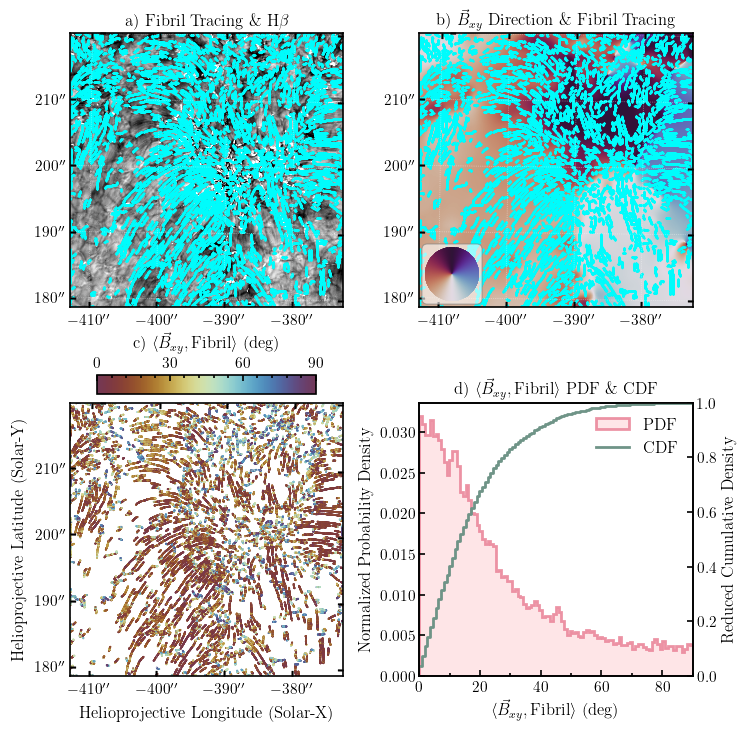

In [158]:
plt.close("all")

display(HTML('<a href="#notebook-top">Go to top</a>'))
display(HTML('<a id="figure-5"></a>'))

with plt.rc_context(ms_style_dict):
    fig = plt.figure(figsize=(9*0.8,11*0.8))
    fig.subplots_adjust(left=0.1, bottom=0.12, top=0.85, right=0.99, wspace=0.2, hspace=0.35)
    ax1 = fig.add_subplot(2,2,1,projection=dkist_vbi_target_cube_crop.wcs)
    ax2 = fig.add_subplot(2,2,2,projection=dkist_vbi_target_cube_crop.wcs)
    ax3 = fig.add_subplot(2,2,3,projection=dkist_vbi_target_cube_crop.wcs)
    ax4 = fig.add_subplot(2,2,4)

    ax1.imshow(fibril_tracing_dict["Hbeta_image"], cmap="gray", origin="lower",
        interpolation="none",
        norm=ImageNormalize(
            vmin=np.nanpercentile(fibril_tracing_dict["Hbeta_image"], 1),
            vmax=np.nanpercentile(fibril_tracing_dict["Hbeta_image"], 99),
        ), rasterized=True)
    
    ax1.scatter(skel_xs, skel_ys, s=0.1, c="cyan", alpha=0.8, rasterized=True)

    im2 = ax2.imshow(b_position_angle, cmap="twilight_shifted", origin="lower",
        interpolation="none", rasterized=True)
    ax2.scatter(skel_xs, skel_ys, s=0.1, c="cyan", alpha=0.8, rasterized=True)
    
    draw_colorwheel(ax2, bbox=[0.02, 0.02, 0.2, 0.2], show_labels=False)

    ax3.scatter(skel_angle_xs, skel_angle_ys, c=angle_b_fibril_vals,
        cmap=cmcm.romaO, s=0.1, vmin=0, vmax=90, rasterized=True)

    im3 = ScalarMappable(norm=ImageNormalize(vmin=0, vmax=90), cmap=cmcm.romaO)
    im3.set_array([])

    clb3, clb_ax3 = plot_colorbar(im3, ax=ax3,
        orientation="horizontal", bbox_to_anchor=(0.1, 1.03, 0.8, 0.07))
    
    clb_ax3.set_xticks([0,30,60,90])
    clb_ax3.tick_params(axis="x", top=True, labeltop=True, bottom=False, labelbottom=False,
    which="both")

    ax3.set_aspect(1)
    ax3.set_xlim(ax2.get_xlim())
    ax3.set_ylim(ax2.get_ylim())

    counts, bin_edges, _ = ax4.hist(angle_b_fibril_vals, bins=100, density=True, range=(0, 90),
        edgecolor="#E87A90", facecolor="#FEDFE1", linewidth=2, alpha=0.8, histtype="stepfilled",
        label="PDF")
    counts_bg = np.nanmean(counts[-10:])
    reduced_counts = counts - counts_bg
    reduced_counts[reduced_counts < 0] = 0
    
    reduced_cdf = np.cumsum(reduced_counts*np.diff(bin_edges))
    reduced_cdf /= reduced_cdf[-1]

    ax4_right = ax4.twinx()
    ax4_right.step((bin_edges[:-1] + bin_edges[1:])/2, reduced_cdf, color="#6F9487", lw=2, where="mid",
        label="CDF")
    ax4_right.set_ylim(0,1)

    ax4.xaxis.set_minor_locator(AutoMinorLocator(2))
    ax4.set_xlim(0, 90)

    handles_ax4, labels_ax4 = ax4.get_legend_handles_labels()
    handles_ax4_right, labels_ax4_right = ax4_right.get_legend_handles_labels()
    ax4.legend(handles_ax4 + handles_ax4_right, labels_ax4 + labels_ax4_right,
        fontsize=12, loc="upper right", frameon=False)

    for ax_ in (ax1,ax2,ax3):
        ax_.grid(True, which="major", ls=":", lw=0.5, color="white", alpha=0.6, zorder=10)

    ax1.coords[0].set_axislabel("", visible=False)
    ax1.coords[1].set_axislabel("", visible=False)
    ax2.coords[0].set_axislabel("", visible=False)
    ax2.coords[1].set_axislabel("", visible=False)
    ax3.coords[0].set_axislabel("Helioprojective Longitude (Solar-X)",
        visible=True, fontsize=12)
    ax3.coords[1].set_axislabel("Helioprojective Latitude (Solar-Y)",
        visible=True, fontsize=12)
    
    ax4.set_xlabel(r"$\langle \vec{B}_{xy}, \mathrm{Fibril} \rangle$ (deg)", fontsize=12)
    ax4.set_ylabel("Normalized Probability Density", fontsize=12)
    ax4_right.set_ylabel("Reduced Cumulative Density", fontsize=12)

    ax1.set_title(r"a) Fibril Tracing \& H$\beta$", fontsize=12)
    ax2.set_title(r"b) $\vec{B}_{xy}$ Direction \& Fibril Tracing", fontsize=12)
    ax3.set_title(r"c) $\langle \vec{B}_{xy}, \mathrm{Fibril} \rangle$ (deg)", fontsize=12)
    ax4.set_title(r"d) $\langle \vec{B}_{xy}, \mathrm{Fibril} \rangle$ PDF \& CDF", fontsize=12)
    
    for ax_ in (ax1,ax2,ax3,ax4,ax4_right, clb_ax3):
        ax_.tick_params(axis='both', which='major', labelsize=11)
    
    pos2 = ax2.get_position()
    pos3 = ax3.get_position()

    new_pos4 = [pos2.x0, pos3.y0, pos2.width, pos3.height]
    ax4.set_position(new_pos4)

    fig.savefig("../../figs/ms_figure/fibril_alignment.pdf", bbox_inches="tight", dpi=150)
    fig.savefig("../../figs/ms_figure_png/fibril_alignment.png", bbox_inches="tight", dpi=150)


    plt.show()


In [120]:
print(reduced_cdf[15], bin_edges[16])

0.5189447208726811 14.4


## Figure A.1
---
Segmentation and skeletonization of H$\beta$ fibrils. (a) H$\beta$ image; (b) G-band image; (c) a merged H$\beta$ and G-band image to reduce background granulation contrast; (d) binary fibril mask; (e) skeletonized and filtered fibril mask; (f) fibril orientation derived from the skeletons, shown using a color wheel.

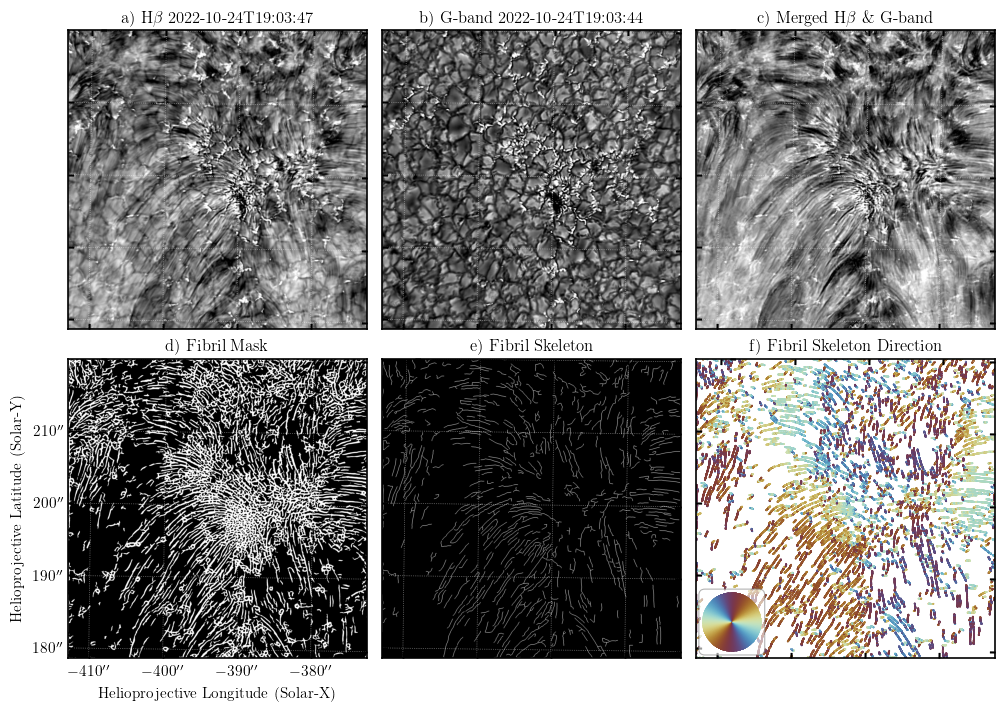

In [156]:
plt.close("all")

display(HTML('<a href="#notebook-top">Go to top</a>'))
display(HTML('<a id="figure-A1"></a>'))

with plt.rc_context(ms_style_dict):
    fig = plt.figure(figsize=(10,7), layout="constrained")
    ax1 = fig.add_subplot(231, projection=dkist_vbi_target_cube_crop.wcs)
    ax2 = fig.add_subplot(232, projection=dkist_vbi_target_cube_crop.wcs)
    ax3 = fig.add_subplot(233, projection=dkist_vbi_target_cube_crop.wcs)
    ax4 = fig.add_subplot(234, projection=dkist_vbi_target_cube_crop.wcs)
    ax5 = fig.add_subplot(235, projection=dkist_vbi_target_cube_crop.wcs)
    ax6 = fig.add_subplot(236, projection=dkist_vbi_target_cube_crop.wcs)

    ax1.imshow(fibril_tracing_dict["Hbeta_image"], cmap="gray", origin="lower",
        norm=ImageNormalize(
            vmin=np.nanpercentile(fibril_tracing_dict["Hbeta_image"], 1),
            vmax=np.nanpercentile(fibril_tracing_dict["Hbeta_image"], 99),
        ), rasterized=True)
    
    ax2.imshow(fibril_tracing_dict["Gband_image"], cmap="gray", origin="lower",
        norm=ImageNormalize(
            vmin=np.nanpercentile(fibril_tracing_dict["Gband_image"], 1),
            vmax=np.nanpercentile(fibril_tracing_dict["Gband_image"], 99),
        ), rasterized=True)
    

    ax3.imshow(fibril_tracing_dict["Hbeta_Gand_image"], cmap="gray", origin="lower",
        norm=ImageNormalize(
            vmin=np.nanpercentile(fibril_tracing_dict["Hbeta_Gand_image"], 1),
            vmax=np.nanpercentile(fibril_tracing_dict["Hbeta_Gand_image"], 99),
        ), rasterized=True)

    ax4.imshow(fibril_tracing_dict["mask"], cmap="gray", origin="lower",
        vmin=0, vmax=1, rasterized=True)

    ax5.imshow(fibril_tracing_dict["grouped_mask"], cmap="gray", origin="lower",
        vmin=0, vmax=0.001, rasterized=True)

    ax6.scatter(skel_angle_xs, skel_angle_ys, c=skel_angle_vals,
        cmap=cmcm.romaO, s=0.1, vmin=0, vmax=180, rasterized=True)

    ax6.set_aspect(1)
    ax6.set_xlim(ax5.get_xlim())
    ax6.set_ylim(ax5.get_ylim())
    
    draw_colorwheel_half(ax6, bbox=[0.02, 0.02, 0.2, 0.2], show_labels=False)

    for ax_ in (ax1,ax2,ax3,ax4,ax5,ax6):
        ax_.grid(True, which="major", ls=":", lw=0.5, color="white", alpha=0.6, zorder=10)
    
    for ax_ in (ax1,ax2,ax3,ax5,ax6):
        ax_.coords[0].set_axislabel("", visible=False)
        ax_.coords[1].set_axislabel("", visible=False)
        ax_.coords[0].set_ticklabel_visible(False)
        ax_.coords[1].set_ticklabel_visible(False)
    
    ax4.set_xlabel("Helioprojective Longitude (Solar-X)", fontsize=11)
    ax4.set_ylabel("Helioprojective Latitude (Solar-Y)", fontsize=11)

    ax4.tick_params(labelsize=11)

    ax1.set_title(r"a) H$\beta$ " + Hbeta_date_obs[30].strftime("%Y-%m-%dT%H:%M:%S"), fontsize=12)
    ax2.set_title(r"b) G-band " + Gband_date_obs[30].strftime("%Y-%m-%dT%H:%M:%S"), fontsize=12)
    ax3.set_title(r"c) Merged H$\beta$ \& G-band", fontsize=12)
    ax4.set_title(r"d) Fibril Mask", fontsize=12)
    ax5.set_title(r"e) Fibril Skeleton", fontsize=12)
    ax6.set_title(r"f) Fibril Skeleton Direction", fontsize=12)

    fig.savefig("../../figs/ms_figure/app_fibril_tracing.pdf", bbox_inches="tight", dpi=150)
    fig.savefig("../../figs/ms_figure_png/app_fibril_tracing.png", bbox_inches="tight", dpi=150)
    plt.show()